In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [5]:
df = pd.read_csv('german_credit_data.csv')

In [6]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


<Axes: xlabel='Risk'>

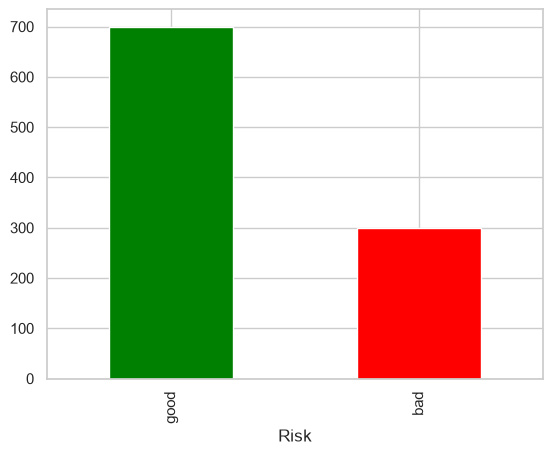

In [7]:
df["Risk"].value_counts().plot(kind='bar', color=['green', 'red'])

In [9]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [22]:
df = df.dropna().reset_index(drop=True)

In [14]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [16]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

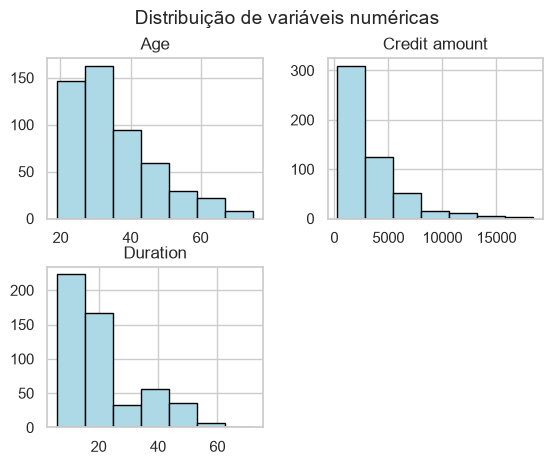

In [24]:
df[['Age', 'Credit amount', 'Duration']].hist(bins=7, edgecolor='black',color ='lightblue')
plt.suptitle('Distribuição de variáveis numéricas', fontsize=14)
plt.show()

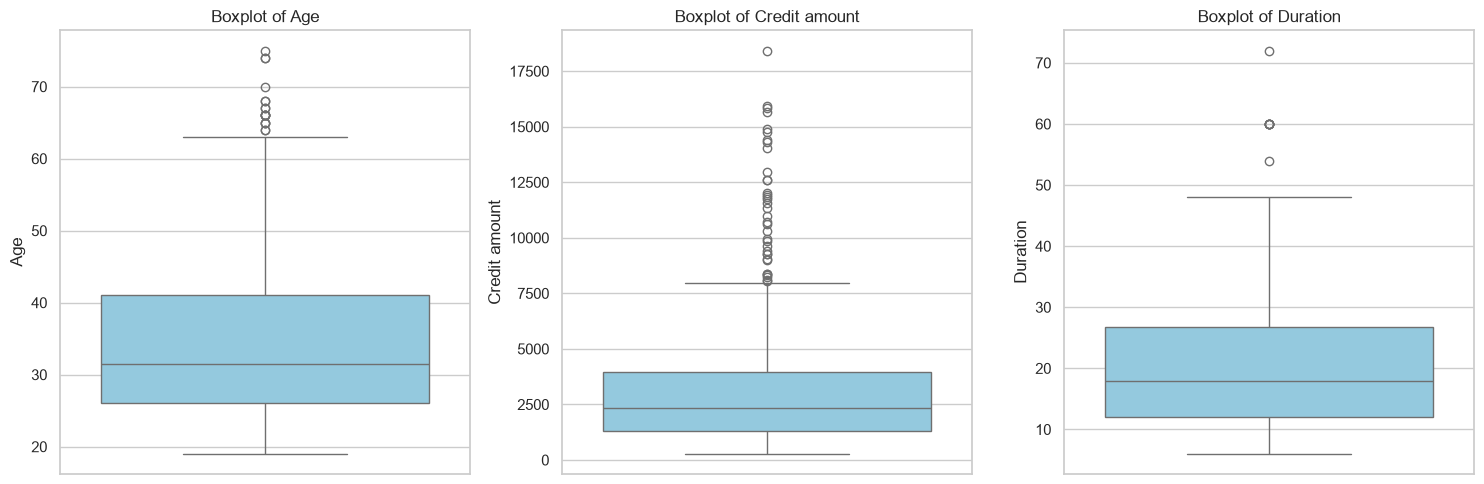

In [27]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y = df[col], color = 'skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [41]:
df[df['Credit amount'] > 7500][['Credit amount']].count()

Credit amount    43
dtype: int64

In [43]:
categorical_columns = ['Sex','Job','Housing','Saving accounts','Checking account','Purpose']

C:\Users\Victor_figueiredo\AppData\Local\Temp\ipykernel_22412\279073669.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, order = df[col].value_counts().index, data=df, palette='Set2')
C:\Users\Victor_figueiredo\AppData\Local\Temp\ipykernel_22412\279073669.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, order = df[col].value_counts().index, data=df, palette='Set2')
C:\Users\Victor_figueiredo\AppData\Local\Temp\ipykernel_22412\279073669.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, order = df[col].value_

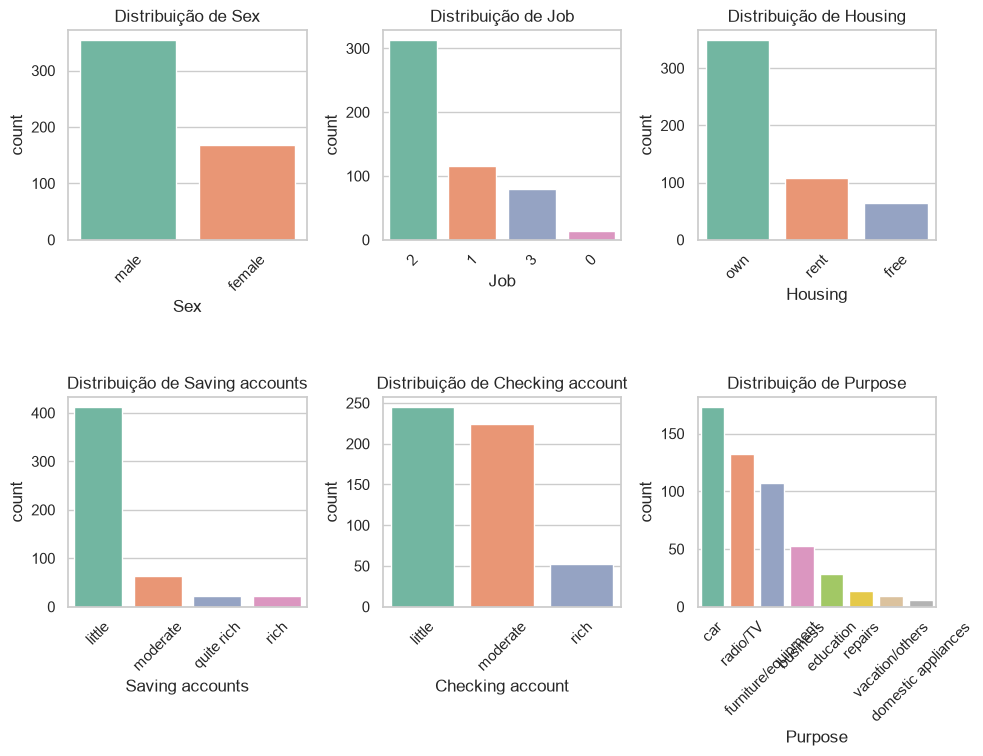

In [48]:
plt.figure(figsize=(10, 10))
for i, col in enumerate(categorical_columns):
    plt.subplot(3,3,i+1)
    sns.countplot(x=col, order = df[col].value_counts().index, data=df, palette='Set2')
    plt.title(f'Distribuição de {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [49]:
corr = df[['Age', 'Job','Credit amount', 'Duration']].corr()

In [50]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


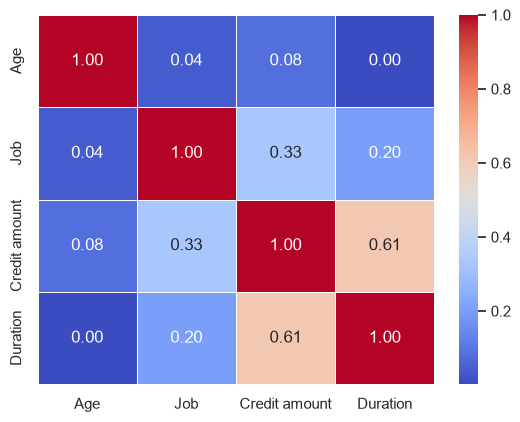

In [51]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

<Axes: xlabel='Job'>

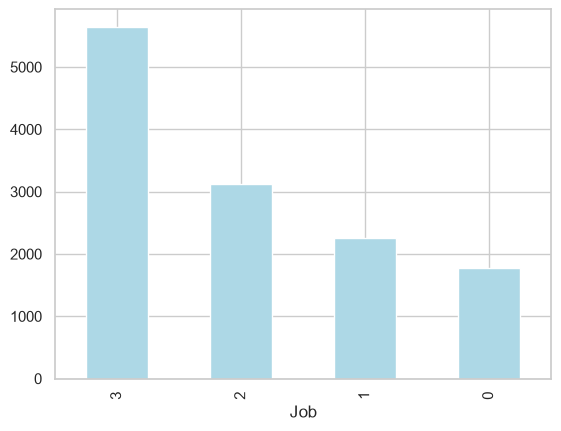

In [52]:
df.groupby('Job')['Credit amount'].mean().sort_values(ascending=False).plot(kind='bar', color='lightblue')

<Axes: xlabel='Sex'>

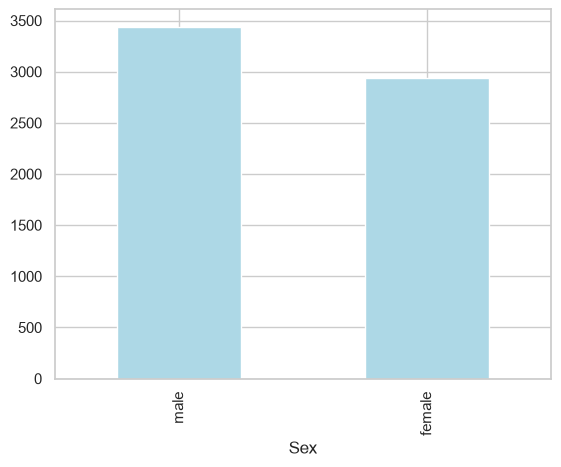

In [53]:
df.groupby('Sex')['Credit amount'].mean().sort_values(ascending=False).plot(kind='bar', color='lightblue')

In [57]:
pd.pivot_table(df, values= 'Credit amount', index = 'Housing', columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


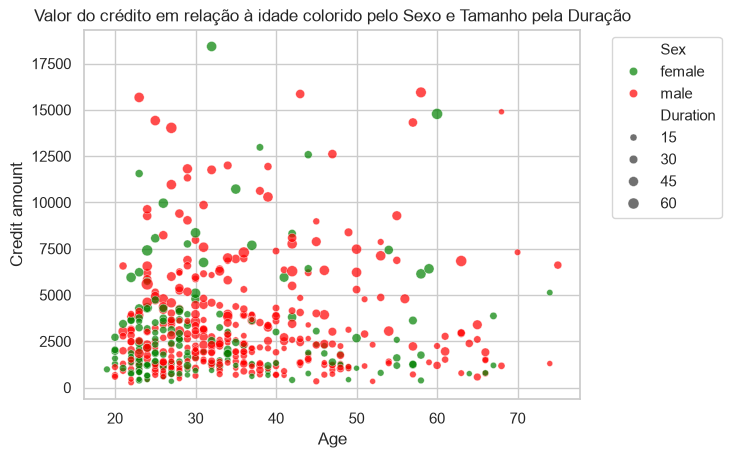

In [62]:
sns.scatterplot(data= df, x= 'Age', y= 'Credit amount', hue='Sex', palette=['green', 'red'], size = 'Duration', alpha=0.7)
plt.title('Valor do crédito em relação à idade colorido pelo Sexo e Tamanho pela Duração') 
plt.legend(bbox_to_anchor=(1.30, 1), loc='upper right')
plt.show()

C:\Users\Victor_figueiredo\AppData\Local\Temp\ipykernel_22412\3926578595.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df, x = 'Saving accounts', y = 'Credit amount', palette = 'Pastel1')


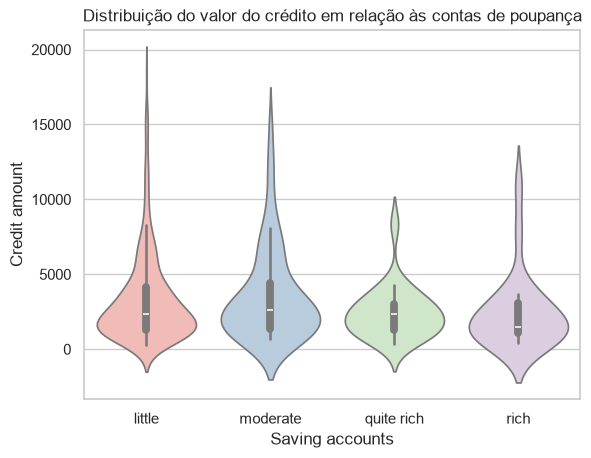

In [65]:
sns.violinplot(data = df, x = 'Saving accounts', y = 'Credit amount', palette = 'Pastel1')
plt.title('Distribuição do valor do crédito em relação às contas de poupança')
plt.show()

In [66]:
df['Risk'].value_counts(normalize=True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

C:\Users\Victor_figueiredo\AppData\Local\Temp\ipykernel_22412\3588252289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk', y=col, data=df, palette='Set2')
C:\Users\Victor_figueiredo\AppData\Local\Temp\ipykernel_22412\3588252289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk', y=col, data=df, palette='Set2')
C:\Users\Victor_figueiredo\AppData\Local\Temp\ipykernel_22412\3588252289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk', y=col, data=df, palette='Set2')


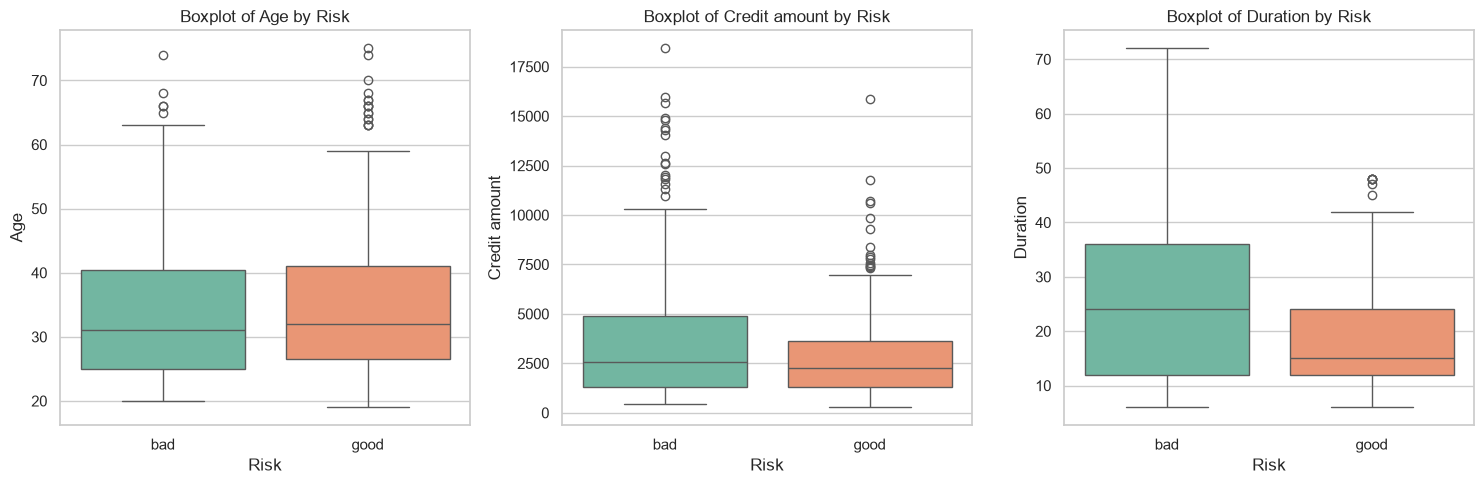

In [69]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(["Age","Credit amount", "Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='Risk', y=col, data=df, palette='Set2')
    plt.title(f'Boxplot of {col} by Risk')
    
plt.tight_layout()
plt.show()

In [70]:
df.groupby('Risk')[['Age', 'Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


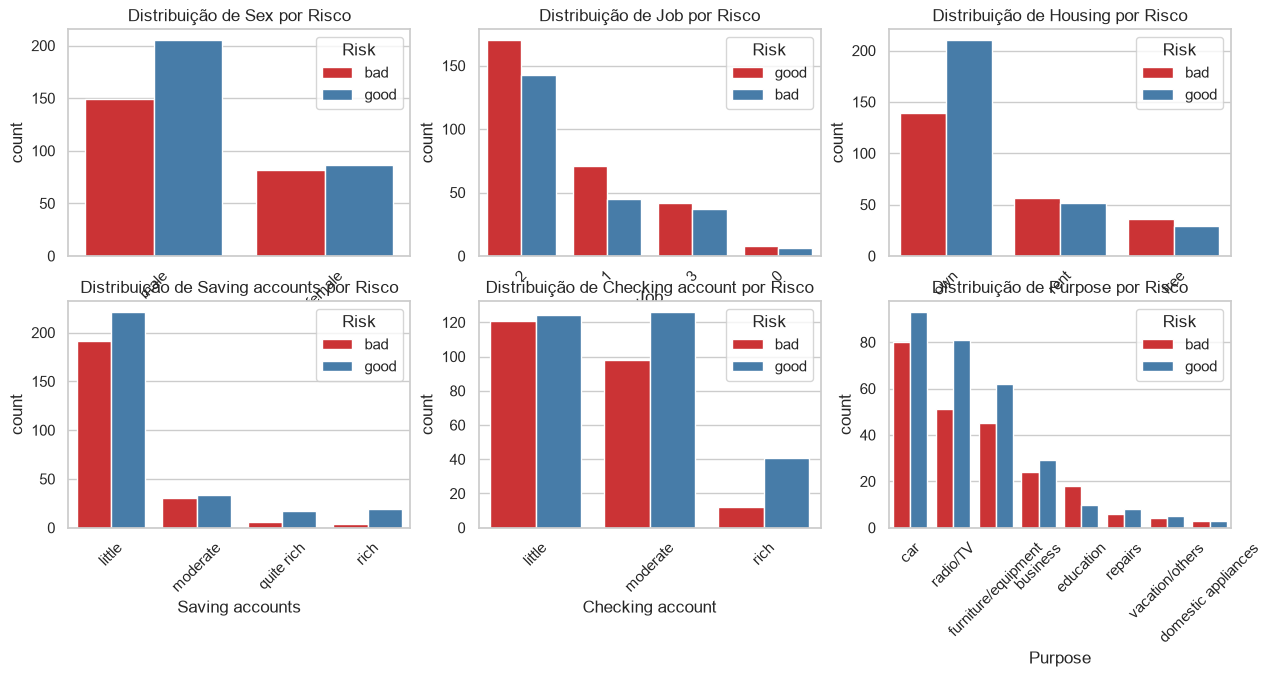

In [75]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_columns):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=col, hue='Risk', data=df, palette='Set1', order = df[col].value_counts().index)
    plt.title(f'Distribuição de {col} por Risco')
    plt.xticks(rotation=45)
    plt.legend(title='Risk', loc='upper right')
    
plt.show()

In [76]:
features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account", "Credit amount", "Duration"]

In [77]:
target = "Risk"

In [78]:
df_model = df[features + [target]].copy()

In [80]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [83]:
from sklearn.preprocessing import LabelEncoder
import joblib